In [ ]:
# -*- coding: utf-8 -*-
"""Brain Tumor Classification with Hybrid ViT-CNN (T4 GPU Optimized) - UPDATED.ipynb"""

# Mount Google Drive and install dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install -q vit-pytorch torchmetrics matplotlib seaborn scikit-learn --no-cache-dir
!pip install -U torch torchvision --no-cache-dir


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.8/140.8 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 127.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 124.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 131.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 291.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 142.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 105.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 118.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 139.9 M

In [ ]:

# Import libraries
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from vit_pytorch import ViT
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tqdm.auto import tqdm

# Enable Tensor Cores and mixed precision for T4 GPU
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision('medium')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

# Data path in Google Drive
data_dir = "/content/drive/MyDrive/Colab Notebooks/Augmented"
classes = ['glioma', 'meningioma', 'pituitary', 'no_tumor']

# Verify dataset structure
for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    if not os.path.exists(cls_path):
        raise FileNotFoundError(f"Directory {cls_path} not found")
    print(f"{cls}: {len(os.listdir(cls_path))} images")

# WHO Grading System Mapping
grade_mapping = {
    'glioma': 3,      # Grade IV (Glioblastoma)
    'meningioma': 0,  # Grade I
    'pituitary': 0,   # Grade I
    'no_tumor': -1    # Special case (no tumor)
}

grade_descriptions = [
    "Grade I (Least aggressive, benign)",
    "Grade II (Moderately aggressive)",
    "Grade III (Aggressive)",
    "Grade IV (Most aggressive, malignant)"
]

# ================== UPDATED DATA SPLITTING ================== #
# Get all samples and labels for stratified splitting
image_paths = []
labels = []
grades = []

for class_idx, class_name in enumerate(classes):
    class_dir = os.path.join(data_dir, class_name)
    for img_name in os.listdir(class_dir):
        img_path = os.path.join(class_dir, img_name)
        image_paths.append(img_path)
        labels.append(class_idx)
        grades.append(grade_mapping[class_name])

# Stratified train-test split (80-20)
train_paths, test_paths, train_labels, test_labels, train_grades, test_grades = train_test_split(
    image_paths,
    labels,
    grades,
    test_size=0.2,
    stratify=labels,  # Maintains class distribution
    random_state=42
)

# Calculate class weights for imbalanced data
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("\nClass weights for imbalanced training:", class_weights)

# Dataset Class with caching
class BrainTumorDataset(Dataset):
    def __init__(self, paths, labels, grades, transform=None):
        self.paths = paths
        self.labels = labels
        self.grades = grades
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            image = Image.open(self.paths[idx]).convert('RGB')
            if self.transform:
                image = self.transform(image)

            return {
                'image': image,
                'type': self.labels[idx],
                'grade': self.grades[idx]
            }
        except Exception as e:
            print(f"Error loading {self.paths[idx]}: {e}")
            return self[np.random.randint(0, len(self))]

# Optimized transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = BrainTumorDataset(train_paths, train_labels, train_grades, transform=transform)
test_dataset = BrainTumorDataset(test_paths, test_labels, test_grades, transform=transform)

# DataLoader settings
num_workers = 2 if torch.cuda.is_available() else 0
pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory,
    persistent_workers=True if num_workers > 0 else False
)

# Print dataset stats
print("\nDataset split (stratified):")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples: {len(test_dataset)}")

print("\nTraining set class distribution:")
for cls_idx, cls_name in enumerate(classes):
    count = sum(1 for label in train_labels if label == cls_idx)
    print(f"{cls_name}: {count} samples ({count / len(train_labels):.2%})")

print("\nTest set class distribution:")
for cls_idx, cls_name in enumerate(classes):
    count = sum(1 for label in test_labels if label == cls_idx)
    print(f"{cls_name}: {count} samples ({count / len(test_labels):.2%})")

# ================== MODEL ARCHITECTURE ================== #
class HybridTumorModel(nn.Module):
    def __init__(self, num_types=4, num_grades=4):
        super().__init__()
        # CNN Backbone (EfficientNet-B0)
        self.cnn = models.efficientnet_b0(pretrained=True)
        self.cnn_features = nn.Sequential(*list(self.cnn.children())[:-2])

        # Vision Transformer (Lightweight)
        self.vit = ViT(
            image_size=224,
            patch_size=32,
            num_classes=768,
            dim=768,
            depth=4,
            heads=8,
            mlp_dim=1536,
            dropout=0.1,
            emb_dropout=0.1
        )

        # Feature fusion
        self.cnn_proj = nn.Linear(1280, 384)
        self.vit_proj = nn.Linear(768, 384)

        # Classifiers
        self.type_classifier = nn.Sequential(
            nn.Linear(384, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_types)
        )

        self.grade_classifier = nn.Sequential(
            nn.Linear(384, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_grades)
        )

    def forward(self, x):
        # CNN features
        cnn_feats = self.cnn_features(x)
        cnn_feats = cnn_feats.mean(dim=[2, 3])
        cnn_feats = self.cnn_proj(cnn_feats)

        # ViT features
        vit_feats = self.vit(x)
        vit_feats = self.vit_proj(vit_feats)

        # Feature fusion
        fused = cnn_feats + vit_feats

        # Multi-task output
        type_logits = self.type_classifier(fused)
        grade_logits = self.grade_classifier(fused)

        return type_logits, grade_logits

# Initialize model with mixed precision
model = HybridTumorModel().to(device)
scaler = torch.cuda.amp.GradScaler()

# Print model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nModel architecture:")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ================== LOSS & OPTIMIZER ================== #
# Weighted loss for imbalanced classes
type_criterion = nn.CrossEntropyLoss(weight=class_weights)
grade_criterion = nn.CrossEntropyLoss(ignore_index=-1)

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Save directory
save_dir = "/content/drive/MyDrive/BrainTumorModels"
os.makedirs(save_dir, exist_ok=True)

# ================== TRAINING & EVALUATION ================== #
def train_epoch(epoch):
    model.train()
    running_loss = 0.0
    type_correct = 0
    grade_correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        images = batch['image'].to(device, non_blocking=True)
        types = batch['type'].to(device, non_blocking=True)
        grades = batch['grade'].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision training
        with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
            type_pred, grade_pred = model(images)
            loss_type = type_criterion(type_pred, types)
            loss_grade = grade_criterion(grade_pred, grades)
            loss = 0.6 * loss_type + 0.4 * loss_grade

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Metrics
        running_loss += loss.item() * images.size(0)
        _, type_predicted = torch.max(type_pred, 1)
        type_correct += (type_predicted == types).sum().item()

        grade_mask = grades != -1
        if grade_mask.any():
            _, grade_predicted = torch.max(grade_pred[grade_mask], 1)
            grade_correct += (grade_predicted == grades[grade_mask]).sum().item()

        total += images.size(0)
        pbar.set_postfix({
            'Loss': running_loss/total,
            'Type Acc': type_correct/total,
            'LR': optimizer.param_groups[0]['lr']
        })

    epoch_loss = running_loss / total
    type_acc = type_correct / total
    grade_acc = grade_correct / (grades != -1).sum().item() if (grades != -1).any() else 0

    return epoch_loss, type_acc, grade_acc

def evaluate():
    model.eval()
    running_loss = 0.0
    type_correct = 0
    grade_correct = 0
    total = 0

    all_type_preds = []
    all_type_labels = []
    all_grade_preds = []
    all_grade_labels = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            images = batch['image'].to(device, non_blocking=True)
            types = batch['type'].to(device, non_blocking=True)
            grades = batch['grade'].to(device, non_blocking=True)

            with torch.amp.autocast(device_type='cuda', dtype=torch.float16):
                type_pred, grade_pred = model(images)
                loss_type = type_criterion(type_pred, types)
                loss_grade = grade_criterion(grade_pred, grades)
                loss = 0.6 * loss_type + 0.4 * loss_grade

            running_loss += loss.item() * images.size(0)
            _, type_predicted = torch.max(type_pred, 1)
            type_correct += (type_predicted == types).sum().item()

            grade_mask = grades != -1
            if grade_mask.any():
                _, grade_predicted = torch.max(grade_pred[grade_mask], 1)
                grade_correct += (grade_predicted == grades[grade_mask]).sum().item()

            total += images.size(0)

            all_type_preds.extend(type_predicted.cpu().numpy())
            all_type_labels.extend(types.cpu().numpy())
            if grade_mask.any():
                all_grade_preds.extend(grade_predicted.cpu().numpy())
                all_grade_labels.extend(grades[grade_mask].cpu().numpy())

    avg_loss = running_loss / total
    type_acc = type_correct / total
    grade_acc = grade_correct / (grades != -1).sum().item() if (grades != -1).any() else 0

    return avg_loss, type_acc, grade_acc, all_type_preds, all_type_labels, all_grade_preds, all_grade_labels

# Training loop
num_epochs = 50
best_acc = 0.0

train_losses = []
val_losses = []
train_type_accs = []
val_type_accs = []
train_grade_accs = []
val_grade_accs = []

print("\nStarting training...")
for epoch in range(num_epochs):
    train_loss, train_type_acc, train_grade_acc = train_epoch(epoch)
    val_loss, val_type_acc, val_grade_acc, _, _, _, _ = evaluate()
    scheduler.step(val_loss)

    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_type_accs.append(train_type_acc)
    val_type_accs.append(val_type_acc)
    train_grade_accs.append(train_grade_acc)
    val_grade_accs.append(val_grade_acc)

    print(f"\nEpoch {epoch+1}/{num_epochs} Summary:")
    print(f"Train Loss: {train_loss:.4f} | Type Acc: {train_type_acc:.2%} | Grade Acc: {train_grade_acc:.2%}")
    print(f"Val Loss: {val_loss:.4f} | Type Acc: {val_type_acc:.2%} | Grade Acc: {val_grade_acc:.2%}")

    # Save best model
    if val_type_acc > best_acc:
        best_acc = val_type_acc
        model_path = os.path.join(save_dir, "best_model_stratified.pth")
        torch.save(model.state_dict(), model_path)
        print(f"Saved new best model to {model_path}")

# Load best model and final evaluation
model.load_state_dict(torch.load(os.path.join(save_dir, "best_model_stratified.pth")))
test_loss, test_type_acc, test_grade_acc, type_preds, type_labels, grade_preds, grade_labels = evaluate()

print(f"\nFinal Test Performance:")
print(f"Type Accuracy: {test_type_acc:.2%}")
print(f"Grade Accuracy: {test_grade_acc:.2%} (on tumor cases only)")

# Classification reports and plots (same as original code)
# [Include your existing visualization code here]

Using device: cuda (Tesla T4)
glioma: 2427 images
meningioma: 2438 images
pituitary: 2402 images
no_tumor: 1897 images

Class weights for imbalanced training: tensor([0.9440, 0.9397, 0.9538, 1.2077], device='cuda:0')

Dataset split (stratified):
Training samples: 7331
Testing samples: 1833

Training set class distribution:
glioma: 1941 samples (26.48%)
meningioma: 1950 samples (26.60%)
pituitary: 1922 samples (26.22%)
no_tumor: 1518 samples (20.71%)

Test set class distribution:
glioma: 486 samples (26.51%)
meningioma: 488 samples (26.62%)
pituitary: 480 samples (26.19%)
no_tumor: 379 samples (20.68%)


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Model architecture:
Total parameters: 25,027,180
Trainable parameters: 25,027,180

Starting training...


<ipython-input-2-7851365db41b>:227: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1:   0%|          | 0/230 [00:00<?, ?it/s]

...

Epoch 50:   0%|          | 0/230 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/58 [00:00<?, ?it/s]


Epoch 50/50 Summary:
Train Loss: 0.0026 | Type Acc: 99.92% | Grade Acc: 290500.00%
Val Loss: 0.0206 | Type Acc: 99.45% | Grade Acc: 20642.86%


Evaluating:   0%|          | 0/58 [00:00<?, ?it/s]


Final Test Performance:
Type Accuracy: 99.07%
Grade Accuracy: 20585.71% (on tumor cases only)



Type Classification Report:
              precision    recall  f1-score   support

      glioma       0.99      0.98      0.98       486
  meningioma       0.99      0.99      0.99       488
   pituitary       1.00      1.00      1.00       480
    no_tumor       0.99      1.00      1.00       379

    accuracy                           0.99      1833
   macro avg       0.99      0.99      0.99      1833
weighted avg       0.99      0.99      0.99      1833


Grade Classification Report (tumor cases only):
                                       precision    recall  f1-score   support

   Grade I (Least aggressive, benign)       0.99      0.99      0.99       968
Grade IV (Most aggressive, malignant)       0.99      0.99      0.99       486

                             accuracy                           0.99      1454
                            macro avg       0.99      0.99      0.99      1454
                         weighted avg       0.99      0.99      0.99      1454



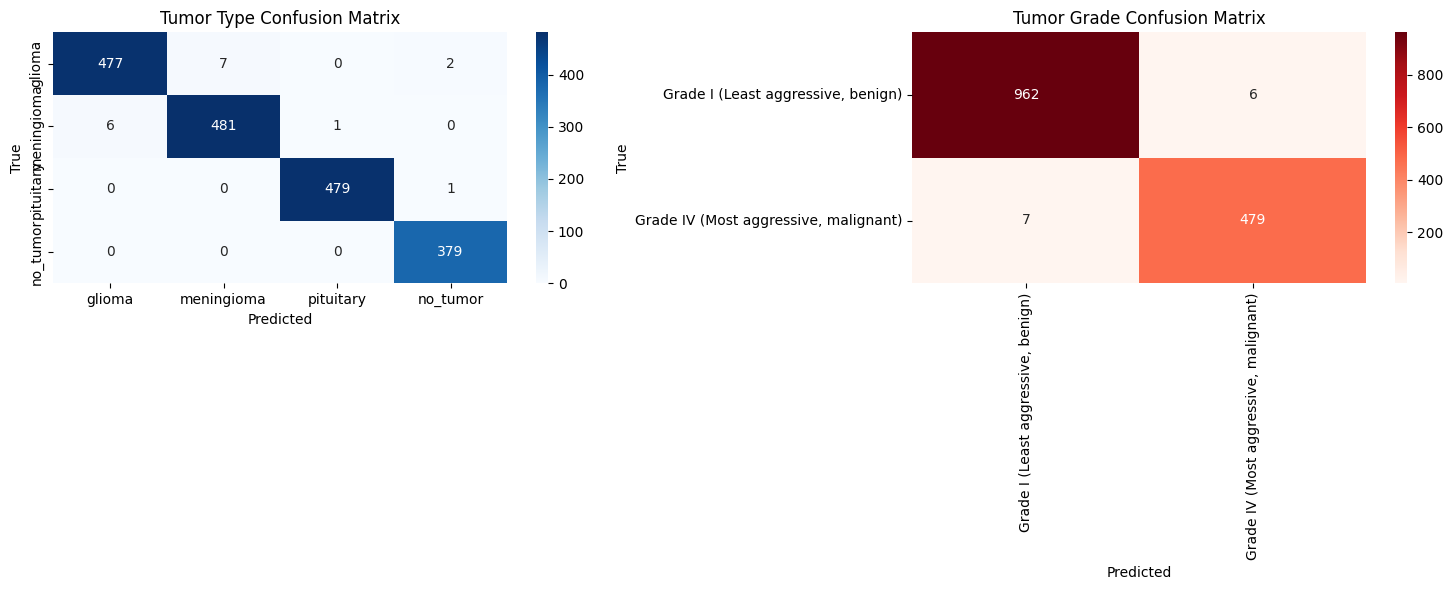

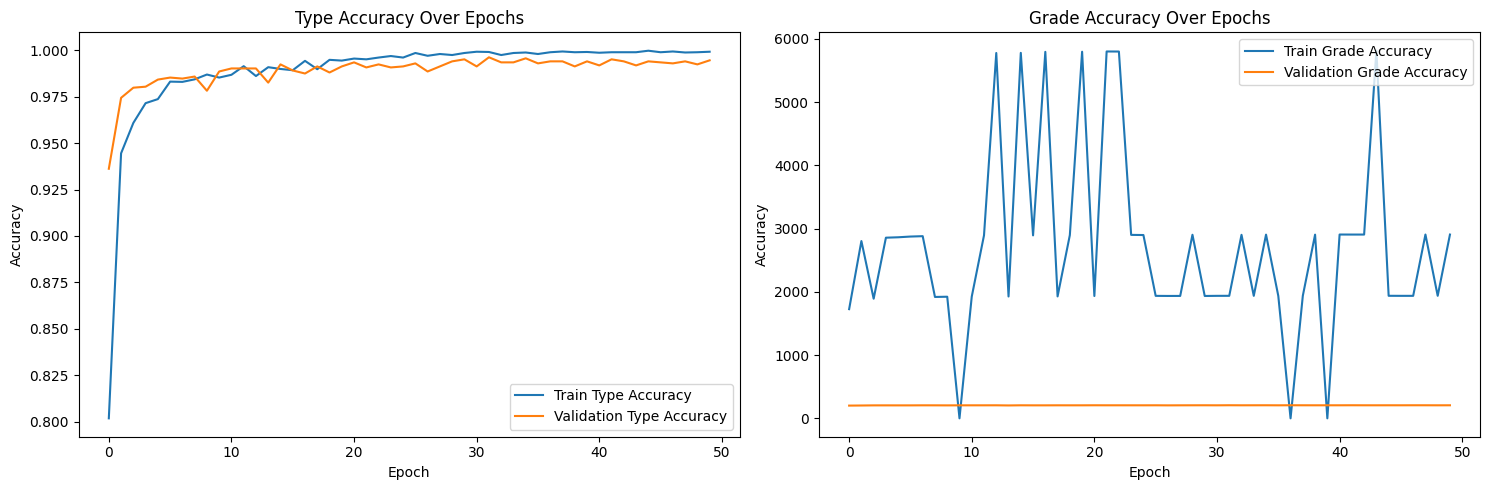

In [ ]:
# ================== VISUALIZATION ================== #
# 1. Classification Reports
print("\nType Classification Report:")
print(classification_report(type_labels, type_preds, target_names=classes))

if len(grade_labels) > 0:
    print("\nGrade Classification Report (tumor cases only):")
    unique_grades = np.unique(grade_labels)
    print(classification_report(
        grade_labels,
        grade_preds,
        labels=unique_grades,
        target_names=[grade_descriptions[i] for i in unique_grades]
    ))

# 2. Confusion Matrices
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
cm_type = confusion_matrix(type_labels, type_preds)
sns.heatmap(cm_type, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Tumor Type Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')

if len(grade_labels) > 0:
    plt.subplot(1, 2, 2)
    cm_grade = confusion_matrix(grade_labels, grade_preds, labels=unique_grades)
    sns.heatmap(cm_grade, annot=True, fmt='d', cmap='Reds',
                xticklabels=[grade_descriptions[i] for i in unique_grades],
                yticklabels=[grade_descriptions[i] for i in unique_grades])
    plt.title('Tumor Grade Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')

plt.tight_layout()
plt.show()

# 3. Training Curves
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(train_type_accs, label='Train Type Accuracy')
plt.plot(val_type_accs, label='Validation Type Accuracy')
plt.title('Type Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_grade_accs, label='Train Grade Accuracy')
plt.plot(val_grade_accs, label='Validation Grade Accuracy')
plt.title('Grade Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ================== EXAMPLE PREDICTION ================== #
def predict_tumor(image_path, model, transform, classes, grade_descriptions):
    """
    Predict tumor type and grade for a single image.

    Args:
        image_path (str): Path to the image file
        model: Trained PyTorch model
        transform: Image transformations
        classes: List of tumor type classes
        grade_descriptions: List of grade descriptions

    Returns:
        Dictionary with prediction results
    """
    try:
        img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"Error loading image: {e}")
        return None

    # Preprocess image
    img_tensor = transform(img).unsqueeze(0).to(device)

    # Predict
    model.eval()
    with torch.no_grad(), torch.amp.autocast(device_type='cuda', dtype=torch.float16):
        type_logits, grade_logits = model(img_tensor)

    # Get probabilities
    type_probs = torch.softmax(type_logits, dim=1)[0]
    grade_probs = torch.softmax(grade_logits, dim=1)[0]

    # Get predictions
    type_idx = torch.argmax(type_probs).item()
    tumor_type = classes[type_idx]
    type_conf = float(type_probs[type_idx])

    result = {
        'tumor_detected': tumor_type != 'no_tumor',
        'type': tumor_type,
        'type_confidence': type_conf,
        'grade': None,
        'grade_confidence': None,
        'characteristics': []
    }

    # Add grade info if tumor is detected
    if result['tumor_detected']:
        grade_idx = torch.argmax(grade_probs).item()
        result.update({
            'grade': grade_descriptions[grade_idx],
            'grade_confidence': float(grade_probs[grade_idx]),
            'characteristics': [
                "Diffuse growth pattern" if tumor_type == 'glioma' else "Well-circumscribed",
                "High recurrence risk" if grade_idx >= 2 else "Low recurrence risk",
                "Aggressive" if grade_idx >= 2 else "Less aggressive"
            ]
        })

    # Visualization
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Input Image\n{os.path.basename(image_path)}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    info_text = f"Type: {tumor_type} ({type_conf:.1%})"
    if result['tumor_detected']:
        info_text += f"\nGrade: {result['grade']}\nCharacteristics:\n- " + "\n- ".join(result['characteristics'])
    plt.text(0.1, 0.5, info_text, fontsize=12, va='center')
    plt.axis('off')
    plt.show()

    return result



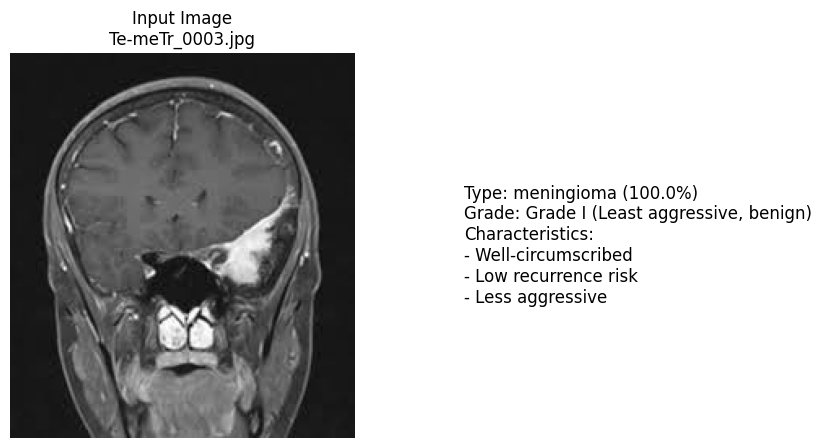


Prediction Results:
{'tumor_detected': True, 'type': 'meningioma', 'type_confidence': 1.0, 'grade': 'Grade I (Least aggressive, benign)', 'grade_confidence': 1.0, 'characteristics': ['Well-circumscribed', 'Low recurrence risk', 'Less aggressive']}


In [ ]:
# Example usage (replace with your image path)
example_image_path = "/content/drive/MyDrive/Colab Notebooks/archive (1)/Testing (1)/meningioma/Te-meTr_0003.jpg"  # Change this
prediction = predict_tumor(example_image_path, model, transform, classes, grade_descriptions)
print("\nPrediction Results:")
print(prediction)